# 6 규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷

### 6.1 규제 선형 모델의 개요

6.1.1 최적 모델을 위한 Cost 함수 구성요소
- Degree 1 - 과소적합 : 지나치게 예측 곡선을 단순화
- Degree 15 - 과(대)적합 : 학습 데이터에만 적합 -> test에서는 형편없음
> 회귀 계수 크기 제어(과적합 방지) + 학습데이터 잔차 오류(RSS) 최소화 = 최적 모델을 위한 Cost 함수 구성요소

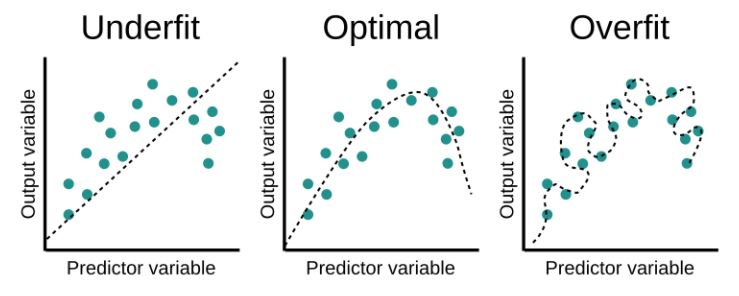

In [2]:
from IPython.display import Image
Image("51.jpg")

6.1.2 비용 함수 목표
- 비용 함수 목표 = Min(RSS(W) + alpha * ||W|||22)을 최소화하는 W를 찾는 것
> alpha : 학습 데이터 적합 정도와 회귀 계수 값의 크기 제어를 수행하는 튜닝 파라미터
> - alpha = 0 인 경우: RSS(W)만 남음
> - alpha = 큰값 인 경우: Min의 값이 무한대로 가지 않기 위해 W를 조정해야함
>> 이처럼 W와 alpha의 값을 조절하며 최소의 비용을 찾는 것

- 규제: 비용 함수에 alpha 값을 ㅗ페널티를 부여해 회귀 계수 값의 크기를 감소시켜 과적합을 개선하는 방식
> - 릿지 회귀 = L2: alpha * ||W||22와 같이 W의 '제곱에 대해 페널티를 부여하는 방식'
> - 라쏘 회귀 = L1: alpha * ||W||1와 같이 W의 절댓값에 대해 페널티 부여 -> L1을 적용하면 영향력이 크지 않은 회귀 계수 값을 0으로 변환

#5.6 편향-분산 트레이드오프(Bias-Variance Trade off)
위의 케이스에서 확인할 수 있듯이..
- 1차: 고편향성
- 15차: 고분산성

> 편향을 낮추고 분산을 높이면서 전체 오류가 가장 낮아지는 '골디락스' 지점을 통과하면서 분산을 지속적으로 높이면 전체 오류 값이 오히려 증가하면서 예측 성능이 다시 저하
>> 편향과 분산이 서로 트레이드오프를 이루면서 오류 cost 값이 최대로 낮아지는 모델을 구축하는 것이 가장 효율적인 머신러닝 예측 모델!

### 6.2 릿지 회귀

In [30]:
#6.2.1 릿지 회귀 - case1. Ridge(alpha=10)
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

#alpha=10으로 설정해 릿지 회귀 수행
ridge = Ridge(alpha = 10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv =5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

print(' 5 folds의 개별 Negative MSE scores: ', np.round(neg_mse_scores,3))
print(' 5 folds의 개별 RMSE scores: ', np.round(rmse_scores,3))
print(' 5 folds의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds의 개별 Negative MSE scores:  [-11.422 -24.294 -28.144 -74.599 -28.517]
 5 folds의 개별 RMSE scores:  [3.38  4.929 5.305 8.637 5.34 ]
 5 folds의 평균 RMSE : 5.518 


6.2.1 결과 리뷰
- linearRegression RMSE 평균 : 5.836
- Ridge RMSE 평균 : 5.518
> Ridge를 적용했을 때 RMSE의 값이 더 작아짐, 더 성능이 좋아졌다!

In [43]:
#6.2.2.1 릿지 회귀 - case2. Ridge(alpha=~~)
## alpha가 커짐에 따라서 W(회귀계수)의 값은 작아짐

#릿지에 사용될 alpha 파라미터의 값을 정의
alphas = [0, 0.1, 1, 10, 100]

#alpha list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas :
    ridge = Ridge(alpha = alpha)

    #cross_val_score를 이용해 5폴드의 평균 RMSE를 계산
    neg_mse_scores=cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv =5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha {0}일 때 5 folds의 평균 RMSE: {1:.3f} '.format(alpha, avg_rmse))

alpha 0일 때 5 folds의 평균 RMSE: 5.829 
alpha 0.1일 때 5 folds의 평균 RMSE: 5.788 
alpha 1일 때 5 folds의 평균 RMSE: 5.653 
alpha 10일 때 5 folds의 평균 RMSE: 5.518 
alpha 100일 때 5 folds의 평균 RMSE: 5.330 


6.2.2 결과 리뷰
- alpha가 100일 때 가장 작은 값을 가짐 

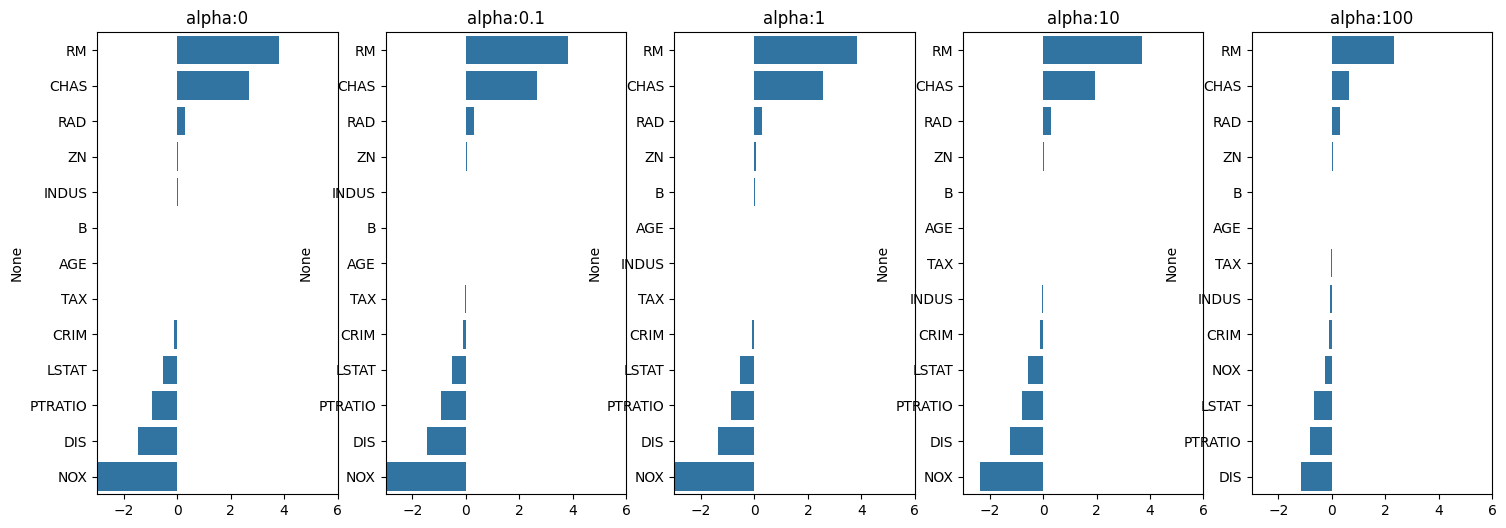

In [42]:
#6.2.2.2 회귀계수 비교를 위한 시각화
# 각 apha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18, 6), nrows=1, ncols=5)
# 각 alLpha에 따른 회귀 계수 값을 데이터로 저장하기 위한 Dataf rane 생성
coeff_df = pd.DataFrame()
# alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장, pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data, y_target)
    # alpha에 따른 피처별로 회귀 계수를 Series로 변환하고 이를 DataFrame의 칼럼으로 추가.
    coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
    colname= 'alpha:'+str(alpha)
    coeff_df[colname] = coeff
    #막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화. 회귀 계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3, 6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])
    # for 문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀 계수를 Dataframe으로 표시

6.2.2.3 시각화 결과 리뷰
- NOX: 일산화질소 농도 (공기 오염도)
> 다양한 피처에 대한 alpha에 따른 회귀계수 값!
>> alpha의 값이 커질수록 회귀계수는 작아지는 것을 확인할 수 있음

In [46]:
# 6.2.2.4 회귀계수 값 출력
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,3.809865,3.818233,3.854000,3.702272,2.334536
CHAS,2.686734,2.670019,2.552393,1.952021,0.638335
RAD,0.306049,0.303515,0.290142,0.279596,0.315358
ZN,0.046420,0.046572,0.047443,0.049579,0.054496
INDUS,0.020559,0.015999,-0.008805,-0.042962,-0.052826
B,0.009312,0.009368,0.009673,0.010037,0.009393
AGE,0.000692,-0.000269,-0.005415,-0.010707,0.001212
TAX,-0.012335,-0.012421,-0.012912,-0.013993,-0.015856
CRIM,-0.108011,-0.107474,-0.104595,-0.101435,-0.102202
LSTAT,-0.524758,-0.525966,-0.533343,-0.559366,-0.660764


### 6.3 라쏘 회귀

6.3.1 L1 vs L2
- L2: 회귀 계수의 크기를 감소시키기
- L1: 불필요한 회귀 계수를 급격하게 감소시켜 0으로 만들고 제거
> 적절한 피처만 포함시키는 피처 선택의 특성을 가짐

In [58]:
#6.3.2.1 라쏘 회귀 - Lasso : get_linear_reg_eval() 함수 정의

from sklearn.linear_model import Lasso, ElasticNet

# alpha값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수값들을 DataFrame으로 반환
def get_linear_reg_eval (model_name, params=None, X_data_n=None, y_target_n=None, verbose=True, return_coeff=True) :
    coeff_df = pd. DataFrame()
    if verbose : print('#######',model_name,'#######' )
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name =='Lasso': model = Lasso(alpha=param)
        elif model_name =='ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring="neg_mean_squared_error", cv = 5)
        avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f} '.format(param, avg_rmse)) # cross_val_score는 evaluation metric 반환하므로 모델을 다시 학습하여 회귀 계수 추출
        
        model. fit(X_data, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀 계수를 Series로 변하고 이를 Dataframe의 칼럼으로 추가.
            coeff = pd.Series(data=model.coef_,index=X_data_n. columns)
            colname='alpha: '+str(param)
            coeff_df[colname] = coeff
    return coeff_df
# end of get_linear_regre_eval

In [59]:
#6.3.2.1 alpha에 따른 결과값 확인
##라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [0.07,0.1,0.5,1,3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

####### Lasso #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.612 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.615 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.669 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.776 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.189 


6.3.2.1 결과 리뷰
- alpha = 0.07일 때 가장 작은 RMSE 
- 릿지 평균보다는 높지만 LinearRegression 평균보다는 향상됨

In [64]:
#6.3.2.2 피처별 회귀 계수
#반환된 coeff_lasso_df를 첫 번째 칼럼순으로 내림차순 정렬해 최귀계수 DataFrame 출력
sort_column = 'alpha: '+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column,ascending=False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
RM,3.789725,3.703202,2.498212,0.949811,0.000000
CHAS,1.434343,0.955190,0.000000,0.000000,0.000000
RAD,0.270936,0.274707,0.277451,0.264206,0.061864
ZN,0.049059,0.049211,0.049544,0.049165,0.037231
B,0.010248,0.010249,0.009469,0.008247,0.006510
NOX,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
AGE,-0.011706,-0.010037,0.003604,0.020910,0.042495
TAX,-0.014290,-0.014570,-0.015442,-0.015212,-0.008602
INDUS,-0.042120,-0.036619,-0.005253,-0.000000,-0.000000
CRIM,-0.098193,-0.097894,-0.083289,-0.063437,-0.000000


### 6.4 엘라스틱넷 회귀

6.4.1 엘라스틱넷 회귀 - ElasticNet()
- 엘라스틱넷 회귀: L2규제와 L1 규제를 결합한 회귀
- 엘라스틱넷 회귀 비용함수의 목표: RSS(W) + alpha2 * ||W||2 + alpha1 * ||W||1식을 최소화하는 W를 찾는 것
> - 장점: L1만 사용할 경우 alpha의 값에 따라 회귀계수의 값이 급변하기에 이를 완화하기 위해 L2 규제를 라쏘 회귀에 추가하는 것
> - 단점: L1과 L2 규제가 결합된 규제로 인해 수행시간이 상대적으로 오래 걸림

- ElasticNet 클래스를 활용
- 주요 생성 파라미터: alpha, l1_ratio
- a(L1의 alpha) * L1 + b(L2의 alpha) * L2
> - alpha 파라미터: a+b
> - l1_ratio: a/(a+b)
>> - l1_ratio = 0 : L2와 동일
>> - l1_ratio = 1 : L1과 동일

In [66]:
#6.4.2 엘라스틱넷 예시
##엘라스틱넷을 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
##l1_ratio는 0.7로 고정
elastic_alphas = [0.07,0.1,0.5,1,3]
coeff_elastic_df=get_linear_reg_eval('ElasticNet',params=elastic_alphas,X_data_n=X_data,y_target_n=y_target)

####### ElasticNet #######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.542 
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.526 
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 5.467 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.597 
alpha 3일 때 5 폴드 세트의 평균 RMSE: 6.068 


In [73]:
#반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column='alpha: '+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha: 0.07,alpha: 0.1,alpha: 0.5,alpha: 1,alpha: 3
RM,3.574162,3.414154,1.918419,0.938789,0.000000
CHAS,1.330724,0.979706,0.000000,0.000000,0.000000
RAD,0.278880,0.283443,0.300761,0.289299,0.146846
ZN,0.050107,0.050617,0.052878,0.052136,0.038268
B,0.010122,0.010067,0.009114,0.008320,0.007020
AGE,-0.010116,-0.008276,0.007760,0.020348,0.043446
TAX,-0.014522,-0.014814,-0.016046,-0.016218,-0.011417
INDUS,-0.044855,-0.042719,-0.023252,-0.000000,-0.000000
CRIM,-0.099468,-0.099213,-0.089070,-0.073577,-0.019058
NOX,-0.175072,-0.000000,-0.000000,-0.000000,-0.000000


#6.4.2 결과 리뷰
- alpha = 0.5에서 RMSE 값이 가장 작음
- alpha 값에 따른 피처들의 회귀 계수들 값이 라쏘보다는 상대적으로 0이 되는 값이 적음 (왜냐하면 Lasso는 0을 바로 떼려버리는 놈이니까)

### 6.5 선형 회귀 모델을 위한 데이터 변환

선형 회귀 모델과 같은 선형 모델의 경우..
1. 피처와 타깃값 간에 선형의 관계가 있다고 가정 > 이러한 최적의 선형함수를 찾아내 결과값을 예측
2. 피처와 타깃값 간의 분포가 정규 분포 형태를 선호
- 특히 타깃값의 경우 정규 분포 형태가 아니라 왜곡된 경우 성능에 영향을 줌 (피처도 동일)
- 따라서 데이터를 먼저 스케일링/정규화 작업을 수행해야함
- [[그 수행하는 방법을 알려주는 장]]

6.5.1 사이킷런을 이용하는 경우

1. StandardScaler 클래스/MinMaxScaler 클래스
2. 스케일링/정규화를 수행한 데이터 세트에 다시 다항 특성을 적용하여 변화하는 방법
- 보통 1번 방법을 통해 예측 성능에 향상이 없을 경우 이와 같은 방법을 적용

3. log변환: log 함수를 적용하면 보다 정규 분포에 가까운 형태로 값이 분포
- 1,2번보다 많이 사용되는 방법
- 왜냐? 1번은 그렇게 효과적X, 2번은 과적합 문제가 생길 수 있음
> 그래서? 타깃값에 로그 변환 적용

In [87]:
# 6.5.2 1,2,3번 방법 순서대로 적용한 결과
#method는 (1) standard (2) MinMax (3) Log 변환
#p_degree는 다항식 특성을 추가할 때 적용. p_degree는 2이상 부여하지 않음

def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data=StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data=MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data=np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree !=None:
        scaled_data=PolynomialFeatures(degree=p_degree,include_bias=False).fit_transform(scaled_data)

    return scaled_data

In [88]:
# Ridge의 alpha값을 다르게 적용하고 다양한 데이터 변환 방법에 따른 RMSE 추출.
alphas = [0.1, 1, 10, 100]

# 5개 방식으로 변환: 원본, 표준정규, 표준정규+다항식, 최소/최대, 최소/최대+다항식, 로그변환
scale_methods = [
    (None, None), ('Standard', None), ('Standard', 2),
    ('MinMax', None), ('MinMax', 2), ('Log', None)
]

for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data=X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1])) 
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, 
                        y_target_n=y_target, verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.788 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.653 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.518 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.330 

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.826 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.803 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.637 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.421 

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 8.827 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.871 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.485 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 4.634 

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.764 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.465 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.754 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.635 

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.298 
alpha 1일 때 5 폴드 세트의 평균 RMSE: 4.323 
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.185 
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.538 

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일 때 5 폴

6.5.2 결과리뷰
1. 방법: 크게 효과X
2. 방법: 효과 있음 > But, 높은 차수에 적용하기 어려움
3. 방법: 결과적으로 Log변환이 가장 좋은 사용하기 좋은 방법

# 7 로지스틱 회귀

### 7.1 로지스틱 회귀란
- 선형 회귀 방식을 분류에 적용하는 알고리즘 (즉, 로지스틱 회귀도 선형 회귀이다!)
- 함수: 선형 함수(X) 시그모이드(sigmoid) 함수(O) 사용 
> - step1. 시그모이드 함수를 찾고
> - step2. 이 시그모이드 함수의 반환 값을 확률로 간주해 확률에 따라 분류로 결정

- 사이킷런의 LogisticRegression 클래스
- 이진 성능에 뛰어남
- 텍스트 분류에서도 자주 사용됨

### 7.2 분류에 적용되는 로지스틱 회귀
- 분류의 경우. 이산형 결과
- 이를 선형 함수로 표현할 수 없음 >> 따라서 시그모이드로 분류 표현

In [2]:
#Step1. 데이터 생성
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [3]:
#Step2. 표준 스케일링 후 훈련/테스트 데이터 분리
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#StandardScalcer()로 평균 0, 분산 1 데이터 분포도 변환
scaler = StandardScaler()
data_scaled=scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

In [4]:
#Step3. 정확도와 ROC-AUC 값을 계산
from sklearn.metrics import accuracy_score, roc_auc_score

#로지스틱 회귀를 이용해 학습 및 예측 수행
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

#정확도와 roc_auc 측정
print('accuracy: {:0.3f}'.format(accuracy_score(y_test, lr_preds)))
print('roc_auc: {:0.3f}'.format(roc_auc_score(y_test, lr_preds)))

accuracy: 0.977
roc_auc: 0.972


In [6]:
#Step4. LogisticRegression 클래스
from sklearn.model_selection import GridSearchCV

params={'penalty' : ['l2', 'l1',], 'C':[0.01, 0.1,1,1,5,10]}

grid_clf = GridSearchCV(lr_clf, param_grid=params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))

최적 하이퍼 파라미터:{'C': 1, 'penalty': 'l2'}, 최적 평균 정확도:0.975


C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
18 fits failed out of a total of 36.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = _check_solver(self.